# 텍스트 분석과 시각화

- 빈도를 바탕으로 한 그래프와 워드 클라우드(word cloud)
- 텍스트 분석은 문서를 구성하는 단어 파악이 핵심
- 예. 대통령 연설문에 사용된 단어들의 빈도 분석 -> 대통령이 중요시하는 것이 무엇인지 의도파악
  - https://cyram.tistory.com/309

## 1. 단어 빈도 그래프 : 가장 많이 쓰인 단어는?

- 토큰화, 어간 추출, 불용어 제거 등 텍스트 데이터 전처리 후 진행

#### 예제 데이터. 
- 영어소설 : 루이스캐럴의 '이상한 나라의 앨리스'
- 구텐베르크 프로젝트 : 저작권 만료 소설 ebook 제공
    - https://www.gutenberg.org

### 1) 데이터 로딩과 텍스트 전처리

In [1]:
from nltk.corpus import gutenberg

gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

- 문서 다운로드 및 내용 확인

In [2]:
doc_alice = gutenberg.open('carroll-alice.txt').read()
print(f'doc_type: {type(doc_alice)}')
print(f'Number of characters: = {len(doc_alice)}')

doc_type: <class 'str'>
Number of characters: = 144395


In [3]:
len('python is powerful language')

27

In [4]:
print(doc_alice[:1500])

[Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, 'and what is the use of a book,' thought Alice 'without pictures or
conversation?'

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure
of making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so VERY remarkable in that; nor did Alice think it so
VERY much out of the way to hear the Rabbit say to itself, 'Oh dear!
Oh dear! I shall be late!' (when she thought it over afterwards, it
occurred to her that she ought to have wondered at this, but at the time
it all seemed quite natural); but

- 토큰화

In [5]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(doc_alice)
print(f'Number of tokens: {len(tokens)}')
print(f'Token sample: {tokens[:20]}')

Number of tokens: 34440
Token sample: ['[', 'Alice', "'s", 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', '1865', ']', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit-Hole', 'Alice', 'was', 'beginning']


- 어간 추출

In [6]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stem_tokens = [stemmer.stem(token) for token in tokens]

print(f'Number of tokens after stemming: {len(stem_tokens)}')
print(f'Token sample after stemming: {stem_tokens[:20]}')

Number of tokens after stemming: 34440
Token sample after stemming: ['[', 'alic', "'s", 'adventur', 'in', 'wonderland', 'by', 'lewi', 'carrol', '1865', ']', 'chapter', 'i', '.', 'down', 'the', 'rabbit-hol', 'alic', 'wa', 'begin']


- 표제어 추출

In [7]:
from nltk.stem import WordNetLemmatizer

lemma = WordNetLemmatizer()
lemma_tokens = [lemma.lemmatize(token) for token in tokens]
print(f'Number of tokens after lemmatization: {len(lemma_tokens)}')
print(f'Token Samples after lemmatization: {lemma_tokens[:20]}')

Number of tokens after lemmatization: 34440
Token Samples after lemmatization: ['[', 'Alice', "'s", 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', '1865', ']', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit-Hole', 'Alice', 'wa', 'beginning']


- 정규표현식을 이용한 토큰화

In [8]:
doc_alice.lower()[:200]

"[alice's adventures in wonderland by lewis carroll 1865]\n\nchapter i. down the rabbit-hole\n\nalice was beginning to get very tired of sitting by her sister on the\nbank, and of having nothing to do: once"

In [9]:
from nltk.tokenize import RegexpTokenizer

reg = RegexpTokenizer(r'\w{3,}')
reg_tokens = reg.tokenize(doc_alice.lower())

In [10]:
from nltk.stem import WordNetLemmatizer

lemma = WordNetLemmatizer()
lemma_tokens = [lemma.lemmatize(token) for token in tokens]
print(f'Number of tokens after RegexpTokenizer: {len(reg_tokens)}')
print(f'Token Samples after RegexpTokenizer: {reg_tokens[:20]}')

Number of tokens after RegexpTokenizer: 21221
Token Samples after RegexpTokenizer: ['alice', 'adventures', 'wonderland', 'lewis', 'carroll', '1865', 'chapter', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginning', 'get', 'very', 'tired', 'sitting', 'her', 'sister']


- 불용어 제거

In [11]:
from nltk.corpus import stopwords

# 1. NLTK 영어 불용어 목록 로드
stop_words = set(stopwords.words('english'))

# 2. 토큰 중에서 불용어에 포함되지 않는 단어만 남기기 
# (이전에 정규표현식 토큰화 결과인 reg_tokens를 사용한다고 가정)
without_sw = [token for token in reg_tokens if token not in stop_words]

print(f'불용어 제거 전 토큰 수: {len(reg_tokens)}')
print(f'불용어 제거 후 토큰 수: {len(without_sw)}')
print(f'불용어 제거 후 샘플: {without_sw[:20]}')

불용어 제거 전 토큰 수: 21221
불용어 제거 후 토큰 수: 12105
불용어 제거 후 샘플: ['alice', 'adventures', 'wonderland', 'lewis', 'carroll', '1865', 'chapter', 'rabbit', 'hole', 'alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'nothing', 'twice', 'peeped', 'book']


- 단어별 빈도

In [12]:
from collections import Counter

alice_word_counter = Counter(without_sw)
print(f'# of tokens: {len(without_sw)}')
print(f'# of words: {len(alice_word_counter)}')
print(f'Top 20 high frequency words:\n{alice_word_counter.most_common(20)}')

# of tokens: 12105
# of words: 2405
Top 20 high frequency words:
[('said', 462), ('alice', 398), ('little', 128), ('one', 104), ('know', 88), ('like', 85), ('would', 83), ('went', 83), ('could', 77), ('queen', 75), ('thought', 74), ('time', 71), ('see', 67), ('well', 63), ('king', 63), ('turtle', 59), ('began', 58), ('way', 56), ('hatter', 56), ('mock', 56)]


- 품사 태깅하여 명사, 동사, 형용사만 추출

In [13]:
from nltk import pos_tag

pos_tag(without_sw)[:20]

[('alice', 'NN'),
 ('adventures', 'NNS'),
 ('wonderland', 'VBP'),
 ('lewis', 'RB'),
 ('carroll', 'JJ'),
 ('1865', 'CD'),
 ('chapter', 'NN'),
 ('rabbit', 'NN'),
 ('hole', 'JJ'),
 ('alice', 'NN'),
 ('beginning', 'VBG'),
 ('get', 'VB'),
 ('tired', 'JJ'),
 ('sitting', 'VBG'),
 ('sister', 'JJ'),
 ('bank', 'NN'),
 ('nothing', 'NN'),
 ('twice', 'RB'),
 ('peeped', 'VBD'),
 ('book', 'NN')]

In [14]:
# NN: 명사(단수), VB: 동사원형, VBD: 동사과거형, JJ: 형용사
tag_set = ['NN', 'VB', 'VBD', 'JJ']

result = [word for word, tag in pos_tag(without_sw) if tag in tag_set]

alice_word_counter2 = Counter(result)
print(f'# of words(NN, VB, VBD, JJ):{len(alice_word_counter2)}')
print(f'Top 20 high frequency words:\n{alice_word_counter2.most_common(20)}')


# of words(NN, VB, VBD, JJ):1601
Top 20 high frequency words:
[('said', 462), ('alice', 301), ('little', 125), ('went', 83), ('queen', 73), ('time', 71), ('began', 58), ('turtle', 58), ('way', 56), ('thought', 54), ('mock', 54), ('thing', 49), ('voice', 48), ('rabbit', 47), ('head', 47), ('gryphon', 46), ('see', 44), ('looked', 43), ('got', 43), ('hatter', 42)]


### 2) 시각화 

In [15]:
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
print(f'matplotlib:{mp.__version__}, seaborn:{sns.__version__}')

matplotlib:3.11.1, seaborn:0.13.2


In [16]:
# 한글코드
plt.rcParams['font.family'] = 'Malgun Gothic'  # 'NanumGothic', 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

#### 전체 단어별 빈도수 시각화

In [17]:
alice_word_counter2['alice']

301

In [18]:
#word_list = [word for word in alice_word_counter2]
#word_freq_list = [alice_word_counter2[word] for word in alice_word_counter2]
## plt.figure(figsize=(20,2))
## plt.plot(word_freq_list)
## plt.bar(word_list, word_freq_list)

In [19]:

# plt.title('이상한 나라의 앨리스: 단어별 빈도 그래프')
# # plt.xticks(rotation=90)
# plt.xticks(range(len(word_freq_list))[::100], word_list[::100], rotation=90)
# plt.xlabel('word')
# plt.ylabel('frequency')
# plt.show()

# 그렇다면 왜 하필 이 코드를 실행했을 때 커널이 비정상 종료(Kernel Died)되었을까요?
# 진짜 원인은 데이터의 오르내림이나 순서 매칭이 아니라,
# 맷플롯립과 주피터 노트북 간의 렌더링 충돌 및 메모리 버그 때문입니다.

# 틱 레이블의 과도한 밀집과 겹침:
# word_list[::100]으로 16개의 단어만 골라 x축 틱(Tick)에 넣으려고 했으나, 맷플롯립 내부적으로 전체 1,601개 데이터 포인트의 X축 레이블 텍스트 렌더링 메커니즘과 충돌을 일으키는 경우가 종종 있습니다.

# C 확장 모듈(Agg 백엔드)의 세그멘테이션 폴트: 주피터 노트북의 인라인 백엔드(matplotlib inline)는 대량의 텍스트 오프셋이나 잘못 계산된 폰트/틱 좌표를 처리할 때 C 레벨에서 메모리 접근 오류를 일으킵니다. 이때 파이썬이 예외 처리를 하지 못하고 프로세스 자체가 통째로 박살 나면서 'Kernel Restarting' 화면이 뜨게 됩니다.

# 즉, 순서가 맞고 틀리고를 떠나서 맷플롯립의 틱 지정 방식과 내부 렌더링 버그가 맞물려 커널을 터뜨린 것입니다. 알파벳순으로 정렬하더라도 틱 인덱스 매핑 과정에서 동일한 내부 충돌 조건이 맞아떨어지면 똑같이 커널이 죽을 수 있습니다.

# 이런 에러를 원천 차단하려면 노트북에 나와 있는 교수님 예시처럼 most_common()을 통해 빈도 내림차순으로 깔끔하게 정렬된 데이터프레임을 만들고, 거기에 맞춰 안전하게 인덱스를 부여하는 방식을 사용하는 것이 가장 확실합니다.

지프의 법칙(Zipf's law)
- 하버드대학교 언어학자 조지 킹슬리 지프가 제안
- 말뭉치의 단어들을 사용빈도가 높은 순서대로 나열하면 단어의 사용빈도는 순위에 반비례한다

#### 빈도수 막대그래프
- 사용 빈도가 높은 상위 20개 단어

In [20]:
# 교수님 ver
import pandas as pd

word_list = [word for word in alice_word_counter2]
word_freq_list = [alice_word_counter2[word] for word in alice_word_counter2]
#word_df = pd.DataFrame(data={'word': word_list, 'count': word_freq_list})
word_df = pd.DataFrame(data=alice_word_counter2.most_common(), columns=['word', 'count'])
word_df

,word,count
0,said,462
1,alice,301
2,little,125
3,went,83
4,queen,73
...,...,...
1596,loving,1
1597,childhood,1
1598,gather,1
1599,wonderland,1


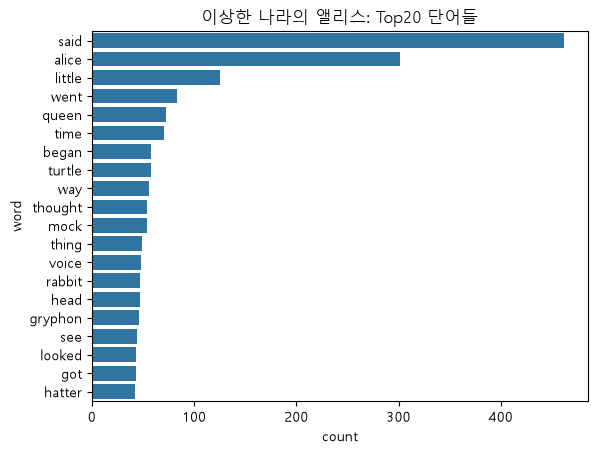

In [21]:
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 손상된 폰트 정보가 기록된 캐시 삭제
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

# 2. 정상 시스템 폰트로 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 3. 중단되었던 시각화 코드 실행
sns.barplot(data=word_df[:20], x='count', y='word')
plt.title('이상한 나라의 앨리스: Top20 단어들')
plt.show()

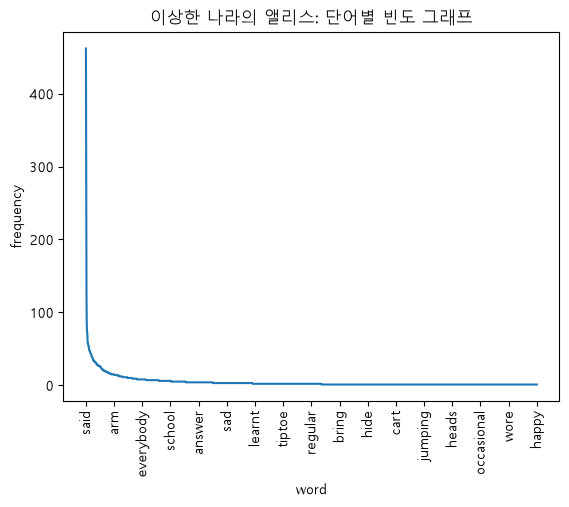

In [22]:
plt.plot(word_df['count'])
plt.title('이상한 나라의 앨리스: 단어별 빈도 그래프')
plt.xticks(range(word_df.shape[0])[::100], word_df['word'][::100], rotation=90)
plt.xlabel('word')
plt.ylabel('frequency')
plt.show()

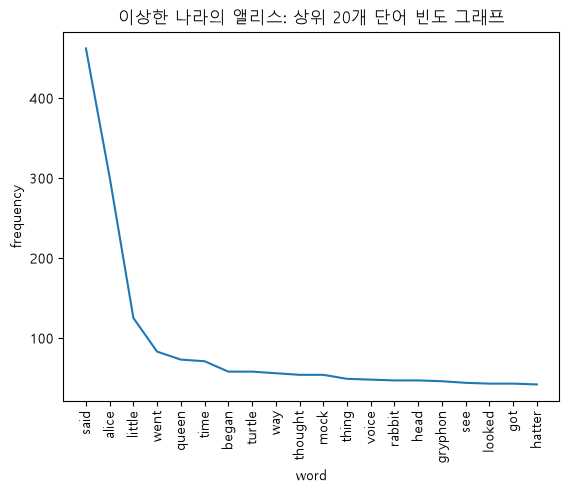

In [23]:
plt.plot(word_df['count'][:20])
plt.title('이상한 나라의 앨리스: 상위 20개 단어 빈도 그래프')
plt.xticks(range(20), word_df['word'][:20], rotation=90)
plt.xlabel('word')
plt.ylabel('frequency')
plt.show()

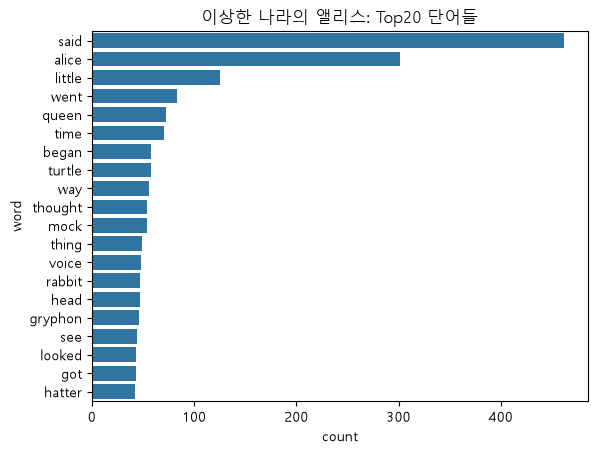

In [24]:
# 여기서 계속 오류남;;; 왜이러지


sns.barplot(data=word_df[:20], x='count', y='word')
plt.title('이상한 나라의 앨리스: Top20 단어들')
plt.show()

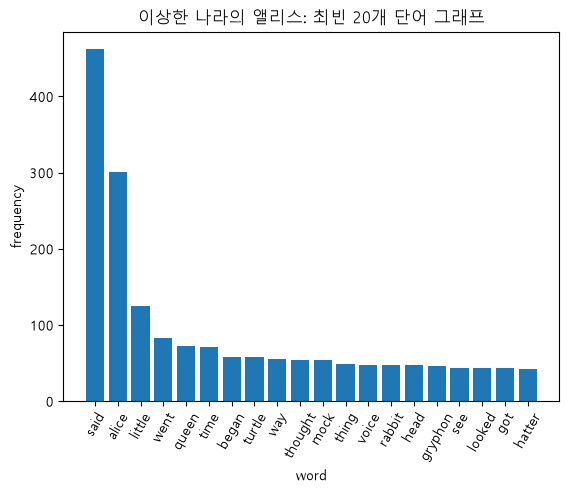

In [25]:
words_sorted = alice_word_counter2.most_common(20)
word_list_sorted = [word for word, count in words_sorted]
word_freq_list_sorted = [count for word, count in words_sorted]

##plt.plot(word_freq_list_sorted[:20])
plt.bar(word_list_sorted[:20], word_freq_list_sorted[:20])

plt.title('이상한 나라의 앨리스: 최빈 20개 단어 그래프')
plt.xticks(rotation=60)
plt.xlabel('word')
plt.ylabel('frequency')
plt.show()



#### 워드 클라우드(word cloud)

- 텍스트 분석 결과를 보여주는 시각화 도구
- 빈도가 높은 단어는 크게, 낮은 단어는 작게 표시
- 단어 빈도 분포를 한 눈에 파악할 수 있음

워드 클라우드 설치

In [26]:
#!pip install wordcloud

In [27]:
import wordcloud
wordcloud.__version__

'1.9.6'

In [28]:
import matplotlib as mpl
import shutil

# 맷플롯립 폰트 캐시 디렉터리 삭제
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

워드 클라우드 이미지 생성 후 plt.imshow()를 이용하여 이미지 출력

In [29]:
from wordcloud import WordCloud

```python
WordCloud(font_path=None ,width=400, height=200,
          margin=2,ranks_only=None, prefer_horizontal=0.9,
          mask=None, scale=1, color_func=None,
          max_words=200, min_font_size=4, stopwords=None,
          random_state=None, background_color='black',
          max_font_size=None, font_step=1, mode='RGB',
          relative_scaling='auto', regexp=None,
          collocations=True, colormap=None,
          normalize_plurals=True,
            contour_width=0,
            contour_color='black',
            repeat=False,
            include_numbers=False,
            min_word_length=0,
            collocation_threshold=30,
)
```

- WordCloud().generate() : 텍스트로부터 워드클라우드 생성

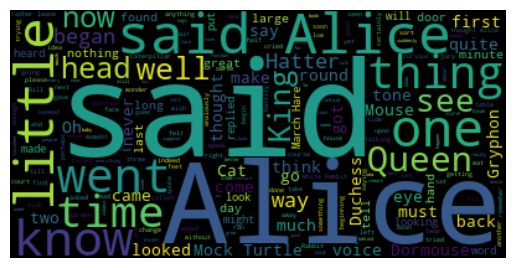

In [30]:
wc = WordCloud().generate(doc_alice)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

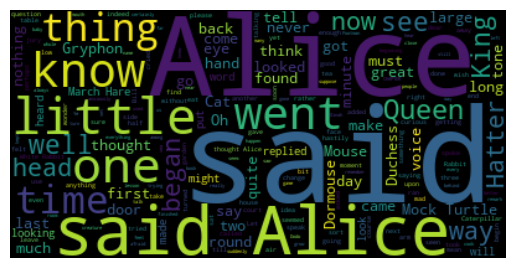

In [31]:
wc = WordCloud().generate(doc_alice)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [32]:
#without_text = ' '.join(set(without_sw))
without_text = ' '.join(without_sw)
without_text[:100]

'alice adventures wonderland lewis carroll 1865 chapter rabbit hole alice beginning get tired sitting'

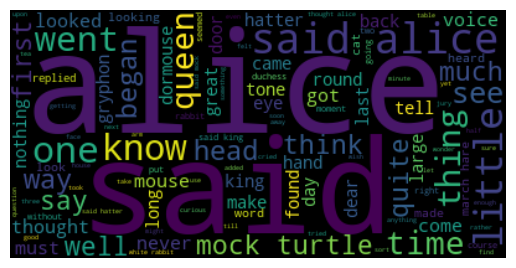

In [33]:
wc = WordCloud().generate(without_text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud 폰트 크기 조절 : max_font_size
- 빈도수가 높은 단어와 낮은 단어의 폰트 크기 차이 조절
- 폰트 최대 크기 제한

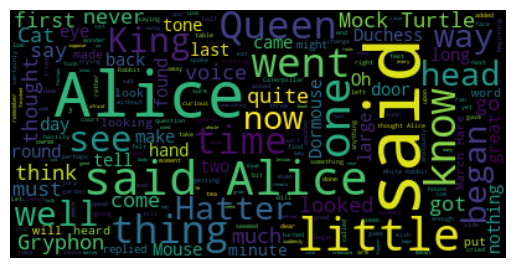

In [34]:
wc2 = WordCloud(max_font_size=60).generate(doc_alice)
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.show()

In [35]:
wc.to_array()

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 9, 45, 42],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], shape=(200, 400, 3), dtype=uint8)

토큰화, 불용어 제거, 품사 태깅 등의 작업 결과 활용한 워드클라우드
- generate_from_frequencies() 메서드
    - 단어와 빈도를 기반으로 워드클라우드 생성

In [36]:
alice_word_counter2.most_common(10)

[('said', 462),
 ('alice', 301),
 ('little', 125),
 ('went', 83),
 ('queen', 73),
 ('time', 71),
 ('began', 58),
 ('turtle', 58),
 ('way', 56),
 ('thought', 54)]

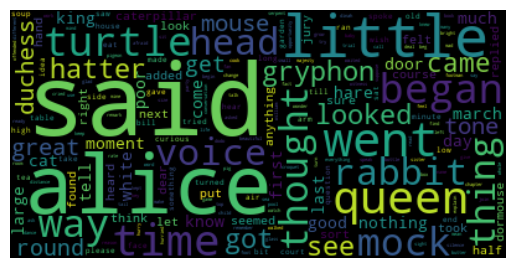

In [37]:
wc3 = WordCloud(max_font_size=80).generate_from_frequencies(alice_word_counter2)
plt.imshow(wc3, interpolation='bilinear')
plt.axis('off')
plt.show()

- 배경색 지정 : background_color='balck' 인수

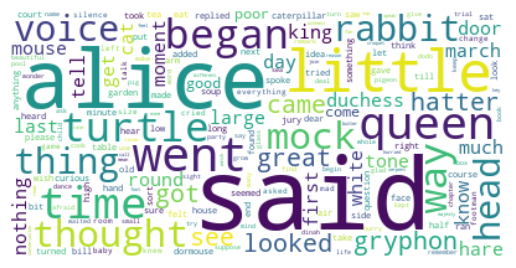

In [38]:
wc4 = WordCloud(max_font_size=80,
                background_color='white'
               ).generate_from_frequencies(alice_word_counter2)
plt.imshow(wc4, interpolation='bilinear')
plt.axis('off')
plt.show()

- 이미지로 저장 : to_file(경로)

In [ ]:
wc4.to_file('img/alice_wordcould01.jpg')

- 최대 표시 단어수 지정 : max_words 인수 기본값 200

In [ ]:
wc5 = WordCloud(max_font_size=80,
                background_color='white',
                max_words=100,
               ).generate_from_frequencies(alice_word_counter2)
plt.imshow(wc5, interpolation='bilinear')
plt.axis('off')
plt.show()

이미지 위에 워드 클라우드 출력
- mask 매개변수 사용

In [ ]:
import numpy as np
from PIL import Image

In [ ]:
# Image.open('img/alice_mast.png')

In [ ]:
alice_mask = np.array(Image.open('img/alice_mask.png'))
wc6 = WordCloud(background_color='white',
                max_words=100,
                mask = alice_mask,
                contour_width=3,
                contour_color='steelblue')
wc6.generate_from_frequencies(alice_word_counter2)
plt.axis('off')
plt.imshow(wc6, interpolation='bilinear')
plt.show()
wc6.to_file('img/alice_wordcloud02.jpg')

- colormap 매개변수 사용
    - `'viridis'`, `'plasma'`, `'Blues'`, `'Reds'`, `'coolwarm'`, `'cool'`
    - 

In [ ]:
for color in ['viridis', 'plasma', 'Blues', 'Reds', 'coolwarm', 'cool']:
    wc7 = WordCloud(background_color='white',
                    colormap=color).generate_from_frequencies(alice_word_counter2)
    plt.axis('off')
    plt.imshow(wc7, interpolation='bilinear')
    plt.show()

## 2. 한국어 문서에 대한 시각화

### 예제 데이터

- KoNLPy에서 제공하는 헌법 텍스트
- https://konlpy.org/ko/latest/data/

### 1) 데이터 준비 및 전처리

#### 데이터 읽기

In [ ]:
from konlpy.corpus import kolaw

doc_const = kolaw.open('constitution.txt').read()
print(f'데이터 형식: {type(doc_const)}')
print(f'문서 글자수: {len(doc_const)}')
print(f'문서 내용: {doc_const[:600]}')

#### 형태소 분석

In [ ]:
from konlpy.tag import Okt

okt = Okt()
tokens = okt.morphs(doc_const)
print(f'토큰 수: {len(tokens)}')
print(f'토큰 일부: \n{tokens[:100]}')

- 명사만 추출

In [ ]:
tokens_noun = okt.nouns(doc_const)
print(f'명사 토큰 수: {len(tokens_noun)}')
print(f'명사 토큰 일부: \n{tokens_noun[:100]}')

#### 한 글자 단어 제외

In [ ]:
tokens2 = [ token for token in tokens if len(token)>=2 ]

In [ ]:
print(f'토큰(두 글자 이상) 수: {len(tokens2)}')
print(f'토큰(두 글자 이상) 일부: \n{tokens2[:100]}')

In [ ]:
tokens3 = [ token for token in tokens_noun if len(token)>=2 ]
print(f'토큰(두 글자 이상 명사) 수: {len(tokens3)}')
print(f'토큰(두 글자 이상 명사) 일부: \n{tokens3[:100]}')

In [ ]:
print(f"=> 전체토큰수: {len(tokens)}개 / 명사만: {len(tokens_noun)}개 / 두글자이상: {len(tokens2)}개 / 명사&두글자이상: {len(tokens3)}개")

### 3) 시각화

#### 빈도 그래프

In [ ]:
from collections import Counter

In [ ]:
const_cnt = Counter(tokens3)
print(const_cnt)
const_df = pd.DataFrame(const_cnt.most_common(), columns=['word','count'])

# const_df = pd.DataFrame(const_cnt)
const_df     

- 상위 20대 단어들에 대한 빈도 그래프

In [ ]:
# 데이터프레임 sns 이용해서 그래프화
sns.barplot(data=const_df.iloc[:20], x='count', y='word')
plt.title('헌법 단어 빈도그래프 Top20')
plt.show()

In [ ]:
# 상위 n개 단어들에 대한 빈도 그래프
def const_top_barplot(df, top=10):
    sns.barplot(data=df.iloc[:top], x='count', y='word')
    plt.title(f'헌법 단어 빈도그래프 Top {top}')
    plt.show()

In [ ]:
const_top_barplot(const_df, top=10)

In [ ]:
# 헌법 문서에서 추출한 상위 20개 빈도그래프 그리기
tokens_pos = Okt().pos(doc_const)
print(f'토큰(품사): {len(tokens_pos)}')
print(f'토큰(품사) 일부:\n{tokens_pos[:20]}')

In [ ]:
# 동사만 추출
tokens_verb = [word for word, tag in tokens_pos if tag == 'Verb']
print(f'토큰(동사): {len(tokens_verb)}')
print(f'토큰(동사) 일부:\n{tokens_verb[:20]}')

In [ ]:
# 길이가 2이상인 동사만 추출
tokens_verb2 = [verb for verb in tokens_verb if len(verb)>=2]
print(f'토큰(동사, 길이가 2이상): {len(tokens_verb2)}')
print(f'토큰(동사, 길이가 2이상) 일부:\n{tokens_verb2[:20]}')

In [ ]:
verb_counter = Counter(tokens_verb2)
verb_df = pd.DataFrame(verb_counter.most_common(), columns=['word','count'])
const_top_barplot(verb_df, top=20)
                        

- 품사를 지정한 경우와 지정하지 않은 경우 빈도그래프 그리기

In [ ]:
def const_top_barplot(df, top=10, pos=None):
    sns.barplot(data=df.iloc[:top], x='count', y='word')
    if pos is None:
        pos = ''
    else:
        pos = pos
    plt.title(f'헌법 단어 빈도그래프 Top {top}')
    plt.show()

In [ ]:
const_top_barplot(verb_df)

In [ ]:
# 문제. 지정된 품사에 대한 빈도 데이터프레임을 생성하고 빈도그래프 그리기

In [ ]:
# 품사 토큰 데이터를 입력으로 받아 지정한 품사와 단어길이를 제한한 토큰들만 추출
# 품사 :
def extract_pos_tag_tokens(tokens_pos, tag_list=['Noun','Verb'], word_len=1):
    '''
    tokens_pos : [('word','tag'),...]
    '''
    return [token for token, tag in tokens_pos if (tag in tag_list) and (len(token) >= word_len)]


# 토큰들의 빈도를 갖는 데이터프레임 생성: 빈도의 내림차순으로 된 데이터프레임 반환
def token_count_df(tokens):
    counter = Counter(tokens)
    return pd.DataFrame(counter.most_common(), columns=['word','count'])

In [ ]:
# Okt() 형태소분석기 사용
tokens_pos = Okt().pos(doc_const)
tag_list = ['Noun','Verb','Adjective']
word_len = 2
tokens = extract_pos_tag_tokens(tokens_pos, tag_list=tag_list, word_len=word_len)
df = token_count_df(tokens)
const_top_barplot(df, top=20, pos='&'.join(tag_list))

#### 워드 클라우드

In [ ]:
doc_const[:200]

- 원 문서를 기반으로 한 워드클라우드

In [ ]:
from wordcloud import WordCloud

font_path = 'C:/Windows/Fonts/malgun.ttf'

wc = WordCloud(font_path = font_path).generate(doc_const)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
wc2 = WordCloud(font_path=font_path,
                max_font_size=100,
                width=800, height=400,
                background_color='white').generate(doc_const)
plt.axis('off')
plt.imshow(wc2, interpolation='bilinear')
plt.show()

In [ ]:
wc3 = WordCloud(font_path=font_path,
                max_font_size=100,
                width=800, height=400,
                background_color='white',
                max_words=50
               ).generate(doc_const)
plt.axis('off')
plt.imshow(wc3, interpolation='bilinear')
plt.show()

- 텍스트 전처리한 데이터 기반의 워드 클라우드

In [ ]:
const_cnt.most_common(10)

In [ ]:
wc4 = WordCloud(font_path=font_path,
                max_font_size=100,
                width=800, height=400,
                background_color='white',
                max_words=50
               ).generate_from_frequencies(const_cnt)

plt.axis('off')
plt.imshow(wc4, interpolation='bilinear')
plt.show()


- 지정한 품사들에 대한 워드클라우드 그리기

In [ ]:
# 워드클라우드 그리기
def draw_wordcloud_cnt(tokens):
    '''
    토큰에 대한 빈도를 계산하여 워드클라우드 그리기
    '''
    cnt = Counter(tokens)
    wc = WordCloud(font_path=font_path,
                   max_font_size=100,
                   width=800, height=400,
                   background_color='white').generate_from_frequencies(cnt)
    plt.axis('off')
    plt.imshow(wc, interpolation='bilinear')
    plt.show()

In [ ]:
tokens_pos = Okt().pos(doc_const)
tag_list = ['Noun','Verb','Adjective']
word_len = 2
tokens = extract_pos_tag_tokens(tokens_pos, tag_list=tag_list, word_len=word_len)
df = token_count_df(tokens)
const_top_barplot(df, top=20, pos='&'.join(tag_list))
draw_wordcloud_cnt(tokens)

### 문제. 다음 단계로 진행되는 코드 작성하기
- 1단계. 품사명을 입력(종료하려면 q를 입력)
- 2단계. 토큰화할 길이 입력
- 3단계. 빈도에 대한 막대그래프와 워드클라우드 그리기

In [ ]:
otk_tag_names = ['명사', '동사', '형용사', '관형사', '부사', '접속사', '감탄사', '조사', '선어말어미', '어미', '접미사', '구두점', '외국어한자및기타기호', '알파벳', '숫자', '미등록어']

In [ ]:
def main():
    okt_tag_names = list(okt_taglist.keys())
    print('품사명은 다음 품사명을 참고하여 한글로 입력해주세요~')
    print(okt_tag_names)
    tag_list = []
    # q입력할 때까지 품사명 입력하여 품사명 리스트 생성
    while True:
        tagname = input('품사명 입력(q입력시 종료):')
        if tagname == 'q':
            break
        tag_list.append()

   # 토큰화 & 시각화(빈도막대그래프, 워드클라우드)
    tokens_pos = Okt().pos(doc_const)
    word_len = 2
    if len(tag_list) >= 1:
        tokens = extract_pos_tag_tokens(tokens_pos, tag_list=tag_list, word_len=word_len)
    else:
        tokens = [word for word, tag in tokens_pos]
    df = token_count_df(tokens)
    const_top_barplot(df, top=20, pos='&'.join(tag_list))
    draw_wordcloud_cnt(tokens)

----